# MoMA Collection - Exploratory Data Analysis

This notebook explores the Museum of Modern Art (MoMA) collection dataset to understand diversity patterns in representation.

## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load datasets
artworks = pd.read_csv('../data/moma-collection/Artworks.csv')
artists = pd.read_csv('../data/moma-collection/Artists.csv')

print(f"Original datasets:")
print(f"Artworks: {len(artworks):,} records")
print(f"Artists: {len(artists):,} records")

Original datasets:
Artworks: 160,248 records
Artists: 15,803 records


## Data Preprocessing

In [2]:
# Clean Artists dataset
# Drop irrelevant columns
artists = artists.drop(columns=['Wiki QID', 'ULAN'])

# Keep only complete records for key diversity analysis columns
key_artist_columns = ['ArtistBio', 'Nationality', 'Gender', 'BeginDate']
artists_clean = artists.dropna(subset=key_artist_columns)

print(f"Artists dataset:")
print(f"Original: {len(artists):,} artists")
print(f"After cleaning: {len(artists_clean):,} artists")
print(f"Retention rate: {(len(artists_clean) / len(artists)) * 100:.1f}%")

Artists dataset:
Original: 15,803 artists
After cleaning: 11,879 artists
Retention rate: 75.2%


In [3]:
# Clean Artworks dataset
# Drop irrelevant columns for diversity analysis
columns_to_drop = [
    'Dimensions', 'Height (cm)', 'Width (cm)', 'Depth (cm)', 
    'Circumference (cm)', 'Diameter (cm)', 'Length (cm)', 
    'Weight (kg)', 'Seat Height (cm)', 'Duration (sec.)',
    'AccessionNumber', 'CreditLine', 'Cataloged', 'OnView',
    'URL', 'ImageURL'
]

artworks = artworks.drop(columns=columns_to_drop)

# Keep only complete records for key diversity analysis columns
key_artwork_columns = [
    'Title', 'Artist', 'ConstituentID', 'ArtistBio', 
    'Nationality', 'BeginDate', 'EndDate', 'Gender', 
    'Date', 'Medium', 'Classification', 'Department'
]

artworks_clean = artworks.dropna(subset=key_artwork_columns)

print(f"Artworks dataset:")
print(f"Original: {len(artworks):,} artworks")
print(f"After cleaning: {len(artworks_clean):,} artworks")
print(f"Retention rate: {(len(artworks_clean) / len(artworks)) * 100:.1f}%")

Artworks dataset:
Original: 160,248 artworks
After cleaning: 144,149 artworks
Retention rate: 90.0%


## Key Findings

### Gender Distribution

Gender Distribution:
male: 9,536 (80.3%)
female: 2,336 (19.7%)
non-binary: 3 (0.0%)
male (trans? ftm?): 1 (0.0%)
gender non-conforming: 1 (0.0%)
transgender woman: 1 (0.0%)
female (transwoman): 1 (0.0%)


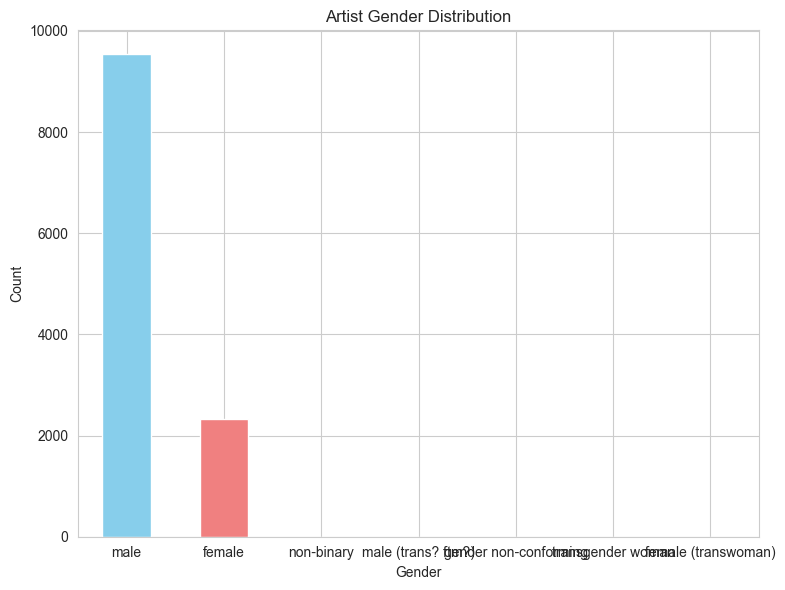

In [4]:
# Gender distribution analysis
gender_counts = artists_clean['Gender'].value_counts()
print("Gender Distribution:")
for gender, count in gender_counts.items():
    percentage = (count / len(artists_clean)) * 100
    print(f"{gender}: {count:,} ({percentage:.1f}%)")

# Visualize
plt.figure(figsize=(8, 6))
gender_counts.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Artist Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Geographic Distribution

Top 15 Nationalities:
American: 4,872 (41.0%)
German: 883 (7.4%)
French: 782 (6.6%)
British: 779 (6.6%)
Italian: 476 (4.0%)
Japanese: 449 (3.8%)
Swiss: 257 (2.2%)
Dutch: 249 (2.1%)
Russian: 245 (2.1%)
Austrian: 225 (1.9%)
Canadian: 182 (1.5%)
Brazilian: 175 (1.5%)
Mexican: 153 (1.3%)
Argentine: 146 (1.2%)
Spanish: 142 (1.2%)


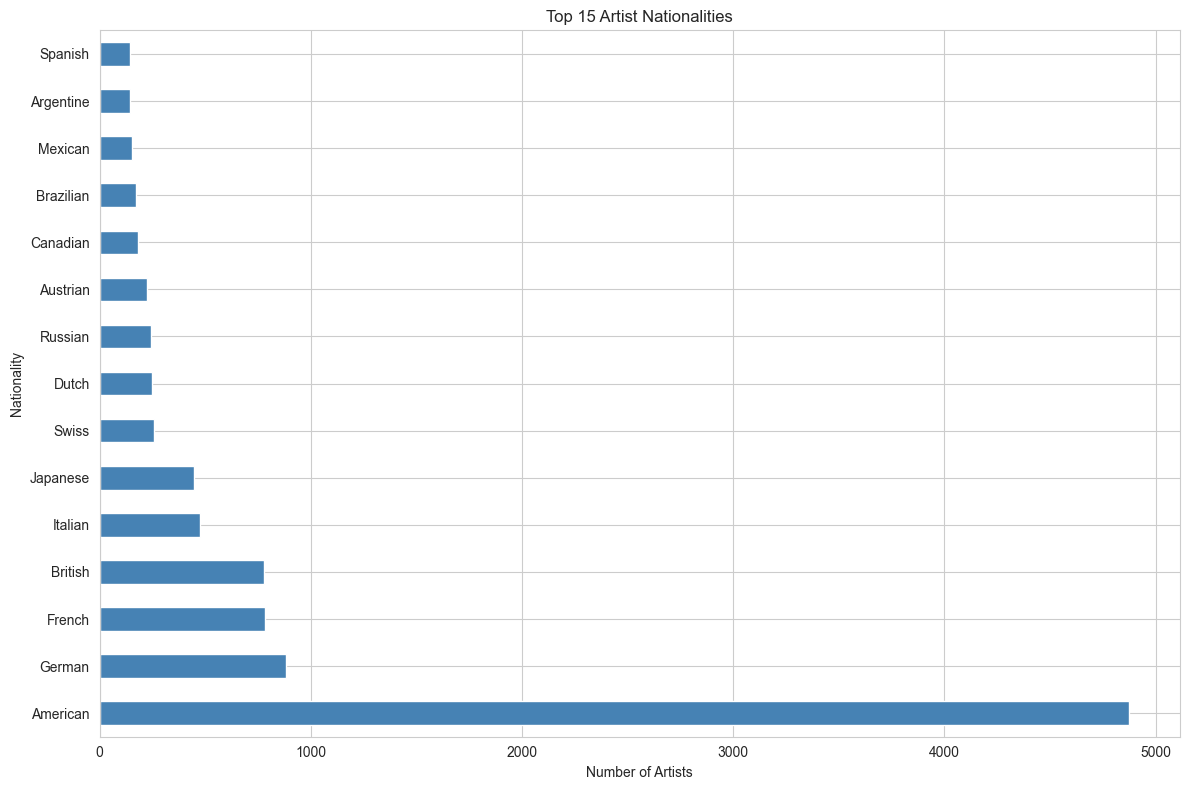

In [5]:
# Top 15 nationalities
top_nationalities = artists_clean['Nationality'].value_counts().head(15)
print("Top 15 Nationalities:")
for nationality, count in top_nationalities.items():
    percentage = (count / len(artists_clean)) * 100
    print(f"{nationality}: {count:,} ({percentage:.1f}%)")

# Visualize
plt.figure(figsize=(12, 8))
top_nationalities.plot(kind='barh', color='steelblue')
plt.title('Top 15 Artist Nationalities')
plt.xlabel('Number of Artists')
plt.ylabel('Nationality')
plt.tight_layout()
plt.show()

In [ ]:
print("=== FINAL CLEANED DATASETS ===")
print(f"Artists: {len(artists_clean):,} records")
print(f"Artworks: {len(artworks_clean):,} records")
print()
print("Key Insights:")
print(f"• Gender imbalance: {(gender_counts['male'] / len(artists_clean) * 100):.1f}% male vs {(gender_counts['female'] / len(artists_clean) * 100):.1f}% female")
print(f"• Geographic concentration: Top 5 nationalities represent {(top_nationalities.head(5).sum() / len(artists_clean) * 100):.1f}% of artists")
print(f"• Department focus: {dept_counts.index[0]} dominates with {(dept_counts.iloc[0] / len(artworks_clean) * 100):.1f}% of collection")
print(f"• Temporal span: {artworks_temporal['Date_numeric'].max() - artworks_temporal['Date_numeric'].min():.0f} years of art history")

=== FINAL CLEANED DATASETS ===
Artists: 11,879 records
Artworks: 144,149 records

Key Insights:
• Gender imbalance: 80.3% male vs 19.7% female
• Geographic concentration: Top 5 nationalities represent 65.6% of artists
• Department focus: Drawings & Prints dominates with 50.1% of collection
• Temporal span: 258 years of art history


### Department Distribution

Artworks by Department:
Drawings & Prints: 72,279 (50.1%)
Architecture & Design: 33,084 (23.0%)
Photography: 30,659 (21.3%)
Painting & Sculpture: 4,072 (2.8%)
Media and Performance: 3,206 (2.2%)
Fluxus Collection: 484 (0.3%)
Film: 334 (0.2%)
Architecture & Design - Image Archive: 31 (0.0%)


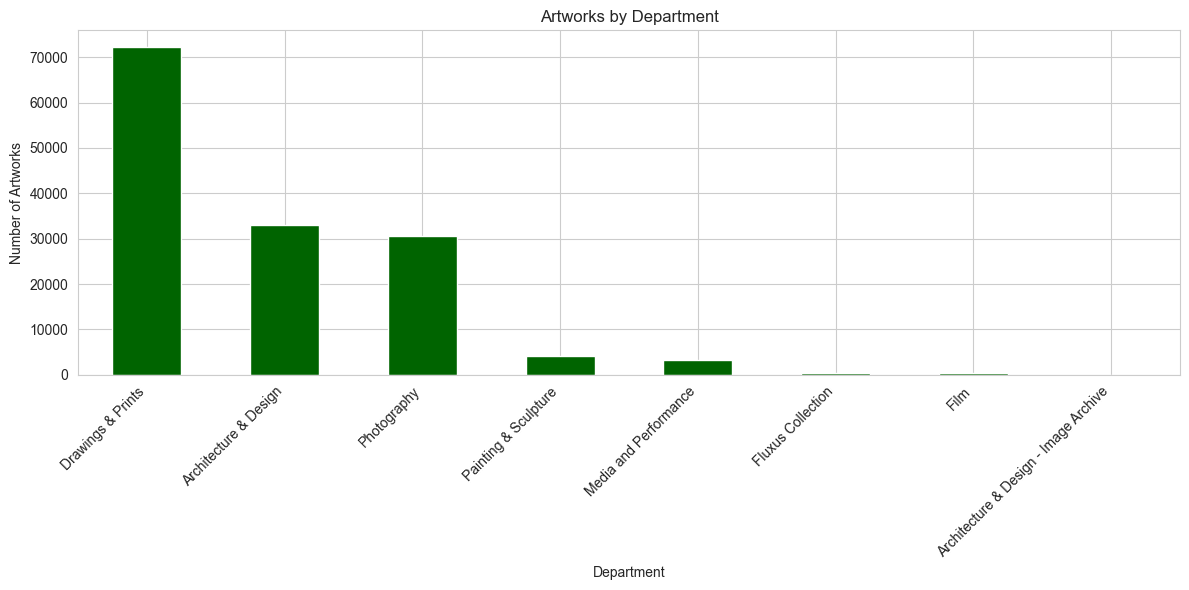

In [6]:
# Department distribution
dept_counts = artworks_clean['Department'].value_counts()
print("Artworks by Department:")
for dept, count in dept_counts.items():
    percentage = (count / len(artworks_clean)) * 100
    print(f"{dept}: {count:,} ({percentage:.1f}%)")

# Visualize
plt.figure(figsize=(12, 6))
dept_counts.plot(kind='bar', color='darkgreen')
plt.title('Artworks by Department')
plt.xlabel('Department')
plt.ylabel('Number of Artworks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Temporal Analysis

Temporal coverage: 1768 - 2026
Artworks with valid dates: 92,564


C:\Users\oussa\AppData\Local\Temp\ipykernel_1428\70485038.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  artworks_clean['Date_numeric'] = pd.to_numeric(artworks_clean['Date'], errors='coerce')
C:\Users\oussa\AppData\Local\Temp\ipykernel_1428\70485038.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  artworks_temporal['Decade'] = (artworks_temporal['Date_numeric'] // 10) * 10


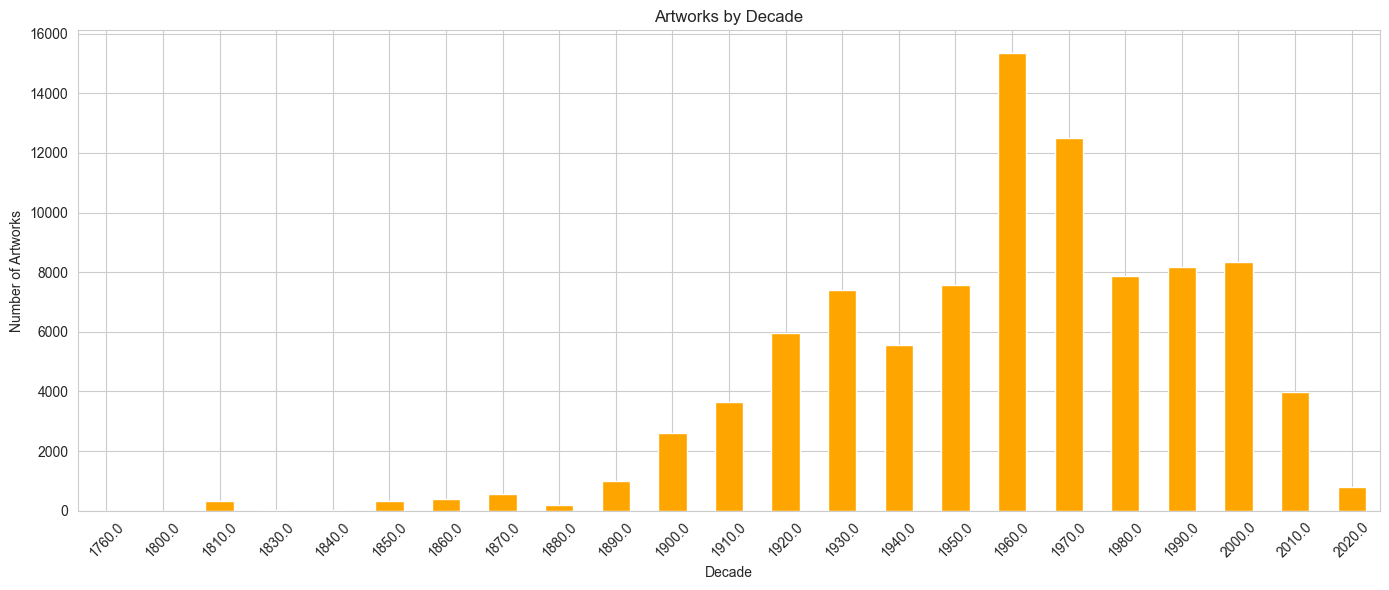

In [7]:
# Convert Date to numeric for temporal analysis
artworks_clean['Date_numeric'] = pd.to_numeric(artworks_clean['Date'], errors='coerce')
artworks_temporal = artworks_clean.dropna(subset=['Date_numeric'])

# Artworks by decade
artworks_temporal['Decade'] = (artworks_temporal['Date_numeric'] // 10) * 10
decade_counts = artworks_temporal['Decade'].value_counts().sort_index()

print(f"Temporal coverage: {artworks_temporal['Date_numeric'].min():.0f} - {artworks_temporal['Date_numeric'].max():.0f}")
print(f"Artworks with valid dates: {len(artworks_temporal):,}")

# Visualize
plt.figure(figsize=(14, 6))
decade_counts.plot(kind='bar', color='orange')
plt.title('Artworks by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Artworks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Summary Statistics

In [8]:
print("=== FINAL CLEANED DATASETS ===")
print(f"Artists: {len(artists_clean):,} records")
print(f"Artworks: {len(artworks_clean):,} records")
print()
print("Key Insights:")
print(f"• Gender imbalance: {(gender_counts['male'] / len(artists_clean) * 100):.1f}% male vs {(gender_counts['female'] / len(artists_clean) * 100):.1f}% female")
print(f"• Geographic concentration: Top 5 nationalities represent {(top_nationalities.head(5).sum() / len(artists_clean) * 100):.1f}% of artists")
print(f"• Department focus: {dept_counts.index[0]} dominates with {(dept_counts.iloc[0] / len(artworks_clean) * 100):.1f}% of collection")
print(f"• Temporal span: {artworks_temporal['Date_numeric'].max() - artworks_temporal['Date_numeric'].min():.0f} years of art history")

=== FINAL CLEANED DATASETS ===
Artists: 11,879 records
Artworks: 144,149 records

Key Insights:
• Gender imbalance: 80.3% male vs 19.7% female
• Geographic concentration: Top 5 nationalities represent 65.6% of artists
• Department focus: Drawings & Prints dominates with 50.1% of collection
• Temporal span: 258 years of art history
